In [49]:
import sys
from pathlib import Path 
import math
import pickle
import bisect
import numpy as np
import time

from dataclasses import dataclass
import random
from collections import defaultdict

W_SIZE = 1000
INF = 10**18
ONLINE_JUDGE = True if len(sys.argv) >= 2 and sys.argv[1] == "ONLINE_JUDGE" else False

def fastcopy(obj):
    return pickle.loads(pickle.dumps(obj, -1))

def debug_print(*args, **kwargs):
    if not ONLINE_JUDGE:
        print(*args, **kwargs)

In [50]:
class Env:
    def __init__(self, input_txt_path: Path):
        self.W, self.D, self.N, self.a = self._input(input_txt_path)

    def _input(self, txt_path):
        with open(txt_path, mode="r") as file:
            lines = file.readlines()
        W, D, N = map(int, lines[0].split())
        a = []
        for line, d in zip(lines[1:], range(D)):
            d = list(map(int, line.split()))
            a.append(d)
        return W, D, N, a

In [51]:
@dataclass
class Rect:
    x1: int
    y1: int
    x2: int
    y2: int

    def calc_area(self):
        return (self.x2 - self.x1) * (self.y2 - self.y1)

In [52]:
def overlap_1d(xl1: int, xr1: int, xl2: int, xr2: int):
    return True if max(xl1, xl2) < min(xr1, xr2) else False


def overlap_1d_ok_just(xl1: int, xr1: int, xl2: int, xr2: int):
    return True if max(xl1, xl2) <= min(xr1, xr2) else False


def overlap_1d_vec_ok_just(vec1: tuple[int, int], vec2: tuple[int, int]):
    return overlap_1d_ok_just(vec1[0], vec1[1], vec2[0], vec2[1])


def overlap_1d_vec(vec1: tuple[int, int], vec2: tuple[int, int]):
    return overlap_1d(vec1[0], vec1[1], vec2[0], vec2[1])


def get_overlap_vec(vec1: tuple[int, int], vec2: tuple[int, int]):
    return (max(vec1[0], vec2[0]), min(vec1[1], vec2[1]))


def concat_1d_vec(vecs: list[tuple[int, int]]) -> list[tuple[int, int]]:
    serched_vecs = []
    for vec in vecs:
        overlap_vecs = [vec]
        non_overlap_vecs = []
        for seached_vec in serched_vecs:
            if overlap_1d_vec_ok_just(vec, seached_vec):
                overlap_vecs.append(seached_vec)
            else:
                non_overlap_vecs.append(seached_vec)
        concat_overlap_vec = (min([v[0] for v in overlap_vecs]), max([v[1] for v in overlap_vecs]))
        serched_vecs = non_overlap_vecs + [concat_overlap_vec]
    return serched_vecs


def evaluate_1d_partition_costs(pre_vecs: list[tuple[int, int]], next_vecs: list[tuple[int, int]]) -> int:
    pre_vecs = concat_1d_vec(pre_vecs)
    next_vecs = concat_1d_vec(next_vecs)

    overlaped_vecs = []
    for pre_vec in pre_vecs:
        for next_vec in next_vecs:
            if overlap_1d_vec(pre_vec, next_vec):
                overlaped_vecs.append(get_overlap_vec(pre_vec, next_vec))

    cost = 0
    cost += sum(vec[1] - vec[0] for vec in pre_vecs)
    cost += sum(vec[1] - vec[0] for vec in next_vecs)

    converged_overlaped_vecs = concat_1d_vec(overlaped_vecs)
    for vec in converged_overlaped_vecs:
        cost -= (vec[1] - vec[0]) * 2
    return cost


def evaluate_partition_rect_cost(pre_rect: list[Rect], next_rect: list[Rect]) -> int:
    pre_rect_x_vecs = defaultdict(list)
    pre_rect_y_vecs = defaultdict(list)
    next_rect_x_vecs = defaultdict(list)
    next_rect_y_vecs = defaultdict(list)

    for rect in pre_rect:
        pre_rect_x_vecs[rect.y1].append((rect.x1, rect.x2))
        pre_rect_x_vecs[rect.y2].append((rect.x1, rect.x2))
        pre_rect_y_vecs[rect.x1].append((rect.y1, rect.y2))
        pre_rect_y_vecs[rect.x2].append((rect.y1, rect.y2))
    for rect in next_rect:
        next_rect_x_vecs[rect.y1].append((rect.x1, rect.x2))
        next_rect_x_vecs[rect.y2].append((rect.x1, rect.x2))
        next_rect_y_vecs[rect.x1].append((rect.y1, rect.y2))
        next_rect_y_vecs[rect.x2].append((rect.y1, rect.y2))

    cost = 0

    x_keys = set(pre_rect_x_vecs.keys()) | set(next_rect_x_vecs.keys())
    for key in x_keys:
        if 0 < key < W_SIZE:
            cost += evaluate_1d_partition_costs(pre_rect_x_vecs[key], next_rect_x_vecs[key])

    y_keys = set(pre_rect_y_vecs.keys()) | set(next_rect_y_vecs.keys())
    for key in y_keys:
        if 0 < key < W_SIZE:
            cost += evaluate_1d_partition_costs(pre_rect_y_vecs[key], next_rect_y_vecs[key])
    return cost


def evaluate_area_cost(target_rects: list[Rect], target_areas: list[int]) -> int:
    cost = 0
    for i in range(len(target_rects)):
        rect_area = abs(target_rects[i].x2 - target_rects[i].x1) * abs(target_rects[i].y2 - target_rects[i].y1)
        if rect_area < target_areas[i]:
            cost += target_areas[i] - rect_area
    return cost * 100


def evaluate_one_day_cost(pre_rect: list[Rect] | None, next_rect: list[Rect], target_areas: list[int]) -> int:
    if pre_rect is None:
        partition_cost = 0
    else:
        partition_cost = evaluate_partition_rect_cost(pre_rect, next_rect)
    area_cost = evaluate_area_cost(next_rect, target_areas)
    return partition_cost + area_cost


def evaluate_all_cost_from_list(ans: list[list[int]], target_areas: list[list[int]]) -> int:
    all_rects = []
    days = len(ans)
    for day in range(days):
        rects = []
        for vec in ans[day]:
            rects.append(Rect(vec[0], vec[1], vec[2], vec[3]))
        all_rects.append(rects)
    return evaluate_all_cost_from_rect(all_rects, target_areas)

def evaluate_all_cost_from_rect(ans: list[list[Rect]], target_areas: list[list[int]]) -> int:
    cost = 0
    days = len(ans)
    for day in range(days):
        if day == 0:
            cost += evaluate_one_day_cost(None, ans[day], target_areas[day])
        else:
            cost += evaluate_one_day_cost(ans[day - 1], ans[day], target_areas[day])
    return cost + 1

In [53]:
def simulate(actions: list[tuple[str, int, float]]) -> list[Rect]:
    parent_rects = [Rect(0, 0, W_SIZE, W_SIZE)]
    for act in actions:
        direction, node, percentail = act
        target_rect = parent_rects[node]
        parent_rects.pop(node)

        if direction == "V":
            if target_rect.x2 - target_rect.x1 <= 1:
                return []
            x = int(target_rect.x1 + (target_rect.x2 - target_rect.x1) * percentail)
            x = min(max(x, target_rect.x1 + 1), target_rect.x2 - 1)
            parent_rects.append(Rect(target_rect.x1, target_rect.y1, x, target_rect.y2))
            parent_rects.append(Rect(x, target_rect.y1, target_rect.x2, target_rect.y2))
        else:
            if target_rect.y2 - target_rect.y1 <= 1:
                return []
            y = int(target_rect.y1 + (target_rect.y2 - target_rect.y1) * percentail)
            y = min(max(y, target_rect.y1 + 1), target_rect.y2 - 1)
            parent_rects.append(Rect(target_rect.x1, target_rect.y1, target_rect.x2, y))
            parent_rects.append(Rect(target_rect.x1, y, target_rect.x2, target_rect.y2))
    return parent_rects

In [54]:
def get_init_actions_rects(n: int) -> tuple[list[tuple[str, int, float]], list[Rect]]:
    while True:
        init_actions: list[tuple[str, int, float]] = []
        for i in range(n-1):
            direction = random.choice(["V", "H"])
            node = random.randint(0, i)
            percentail = random.random()
            init_actions.append((direction, node, percentail))
        rects = simulate(init_actions)
        if rects:
            return init_actions, rects

In [55]:
def change_neaby_actions(actions: list[tuple[str, int, float]]) -> list[tuple[str, int, float]]:
    new_actions = fastcopy(actions)
    idx = random.randint(0, len(actions)-1)
    direction, node, percentail = actions[idx]
    if random.random() < 0.1:
        direction = random.choice(["V", "H"])
    elif random.random() < 0.1:
        node = random.randint(0, idx)
    else:
        random_diff = (0.5 - random.random()) / 20
        percentail = min(max(0.0, percentail + random_diff), 1.0)
    new_actions[idx] = (direction, node, percentail)
    return new_actions

In [56]:
def simulate_anneling(target_areas, day, pre_rects: list[Rect] = None, pre_actions: list[tuple[str, int, float]] = None, next_best_actions: list[tuple[str, int, float]] = None):
    days = len(target_areas)
    n = len(target_areas[0])
    if pre_actions:
        best_actions = pre_actions
        x_best = simulate(best_actions)
    else:
        best_actions, x_best = get_init_actions_rects(n)
    fx_best = evaluate_one_day_cost(pre_rects, x_best, target_areas[day])
    
    SIMULATE_N = 100000
    for i in range(SIMULATE_N):
        changed_actions = change_neaby_actions(best_actions)
        now_rects = simulate(changed_actions)
        if not now_rects:
            continue
        now_rects = sorted(now_rects, key=lambda x: x.calc_area())
        fx = evaluate_one_day_cost(pre_rects, now_rects, target_areas[day])
        next_cost = 0
        for d in range(day+1, days):
            weight = (1/4) ** (day+1 - d)
            next_cost +=  evaluate_area_cost(now_rects, target_areas[d]) * (1- i/SIMULATE_N) * weight * 0.0001
        fx += next_cost
        if fx < fx_best:
            x_best = now_rects
            fx_best = fx
            best_actions = changed_actions
        if i % 5000 == 0:
            print(f"{i}/{SIMULATE_N} {fx_best} {next_cost}")
    
    return x_best, best_actions

In [57]:
def solve(env: Env):
    ans = []
    for d in range(env.D):
        print(f"day {d}")
        if d == 0:
            x_best, best_actions, next_bests = simulate_anneling(env.a, d)
        else:
            x_best, best_actions, next_bests = simulate_anneling(env.a, d, x_best, best_actions, next_bests)
        ans.append(x_best)
    return ans

In [58]:
i = 0

debug_print(f"----- {i}/100 -----")
input_txt_path = Path(f"./in/{str(i).zfill(4)}.txt")
output_txt_path = Path(f"./out/{str(i).zfill(4)}.txt")
env = Env(input_txt_path)

ans = solve(env)
cost = evaluate_all_cost_from_rect(ans, env.a)
debug_print(f"cost:{cost}")

str_ans = []
for d in range(env.D):
    for k in range(env.N):
        r: Rect = ans[d][k]
        i0, j0, i1, j1 = r.x1, r.y1, r.x2, r.y2
        str_ans.append(f"{i0} {j0} {i1} {j1}")

with open(output_txt_path, mode="w") as file:
    file.write("\n".join(str_ans))

----- 0/100 -----
day 0
0/100000 21981769.29 240369.28999999998
5000/100000 483.6799555 7012.634
10000/100000 458.23463770000006 2293.578
15000/100000 424.4089164 3627.4260000000004
20000/100000 398.7539686 1601.944
25000/100000 368.44732500000003 516.2625
30000/100000 343.95851250000004 554.883
35000/100000 319.33214999999996 2182.1605
40000/100000 294.86298750000003 3115.2780000000002
45000/100000 270.2906625 816.8435000000001
50000/100000 245.63973750000002 518.0250000000001
55000/100000 221.0625 221.0625
60000/100000 196.5442125 110415.20000000001
65000/100000 171.99645 439.8415
70000/100000 147.37991250000002 277.35900000000004
75000/100000 122.82723749999998 967.44
80000/100000 98.29912499999998 319.17799999999994
85000/100000 73.75136249999998 81.19500000000002
90000/100000 49.164299999999976 346.469
95000/100000 24.5674125 284.87600000000026
day 1
0/100000 6256630.24 30.240000000000002
5000/100000 16789.939086 40099.9655
10000/100000 16010.026448 5765.94
15000/100000 15639.6209

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def display_map(rects: list[Rect]):
    fig = plt.figure(figsize=(5, 5))
    ax = plt.axes()

    r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
    ax.add_patch(r)

    for rect in rects:
        width = rect.x2 - rect.x1
        height = rect.y2 - rect.y1
        r = patches.Rectangle(xy=(rect.x1, rect.y1), width=width, height=height, ec='#000000', fill=True)
        ax.add_patch(r)

    plt.xlim(-5, 1005)
    plt.ylim(-5, 1005)
    plt.axis('off')
    ax.set_aspect('equal')
    plt.show()

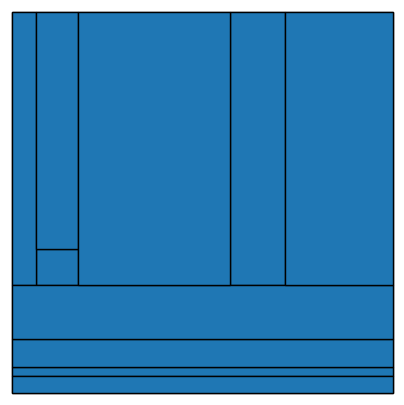

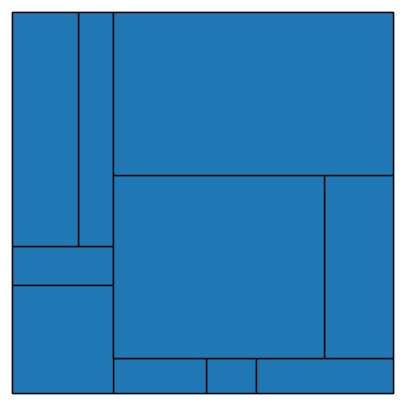

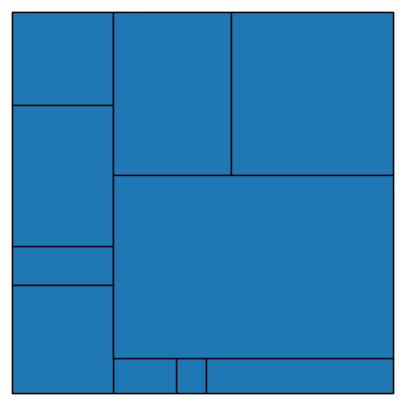

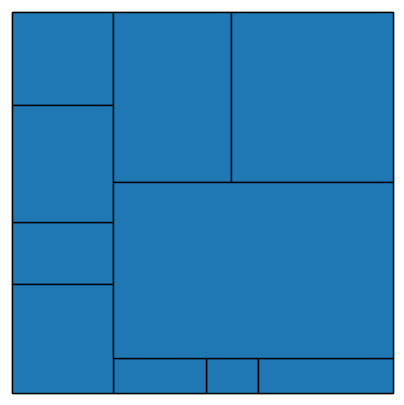

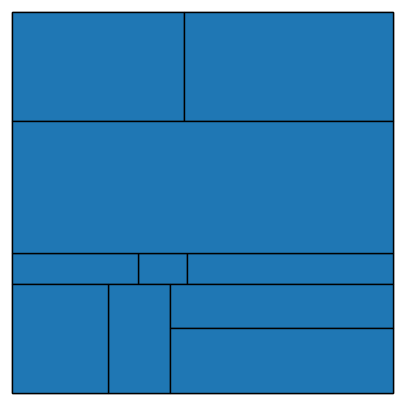

In [60]:
for d in range(env.D):
    display_map(ans[d])